# Analise 5 - Uso Alto de Redes Sociais, Pouco Sono e Indicativo de Depressão

## 1. Introdução
O uso intenso de redes sociais e a baixa quantidade de sono são dois fatores que podem aparecer juntos na rotina de adolescentes. Um jovem que passa muitas horas por dia nas redes sociais pode acabar dormindo menos, principalmente quando também utiliza telas por muito tempo antes de dormir. Por isso, esta análise busca observar se a combinação entre alto uso de redes sociais e pouco sono está relacionada a uma maior presença de indicativo de depressão na base.

Nesta análise, o foco não é olhar apenas para uma variável isolada. A ideia é criar um grupo específico de adolescentes que possuem, ao mesmo tempo, alto tempo diário de redes sociais e baixa quantidade de sono. Depois, esse grupo será comparado com os demais adolescentes da base.

## 2. Objetivo
Os objetivos principais desta seção são:
* Criar um grupo de adolescentes com alto uso de redes sociais e pouco sono.
* Comparar o percentual de indicativo de depressão (`depression_label`) entre esse grupo e os demais adolescentes.
* Verificar se a combinação dessas duas variáveis apresenta uma diferença relevante no percentual de depressão.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para construir os grupos de comparação:
* `dados_limpos.csv`: Base consolidada com dados de rotina, redes sociais, sono e saúde mental.

Para esta análise, foi considerado:
* **Uso alto de redes sociais:** adolescentes com `daily_social_media_hours >= 6`.
* **Pouco sono:** adolescentes com `sleep_hours < 6`.
* **Grupo de risco:** adolescentes que atendem às duas condições ao mesmo tempo.

### 3.1 Carregamento e Pré-processamento dos Dados


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('../../bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Uso Alto de Redes Sociais + Pouco Sono vs Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de barras para comparar o percentual de adolescentes com indicativo de depressão em dois grupos:
* **Grupo 1:** Uso alto de redes sociais + pouco sono.
* **Grupo 2:** Demais adolescentes.

**Hipótese:** O grupo com alto uso de redes sociais e pouco sono deve apresentar maior percentual de indicativo de depressão, porque combina dois fatores que podem estar relacionados ao desgaste emocional e à piora da rotina.


,grupo_uso_sono,total,casos_depressao,percentual_depressao
0,Uso alto + pouco sono,139,23,16.546763
1,Demais adolescentes,1061,8,0.754006


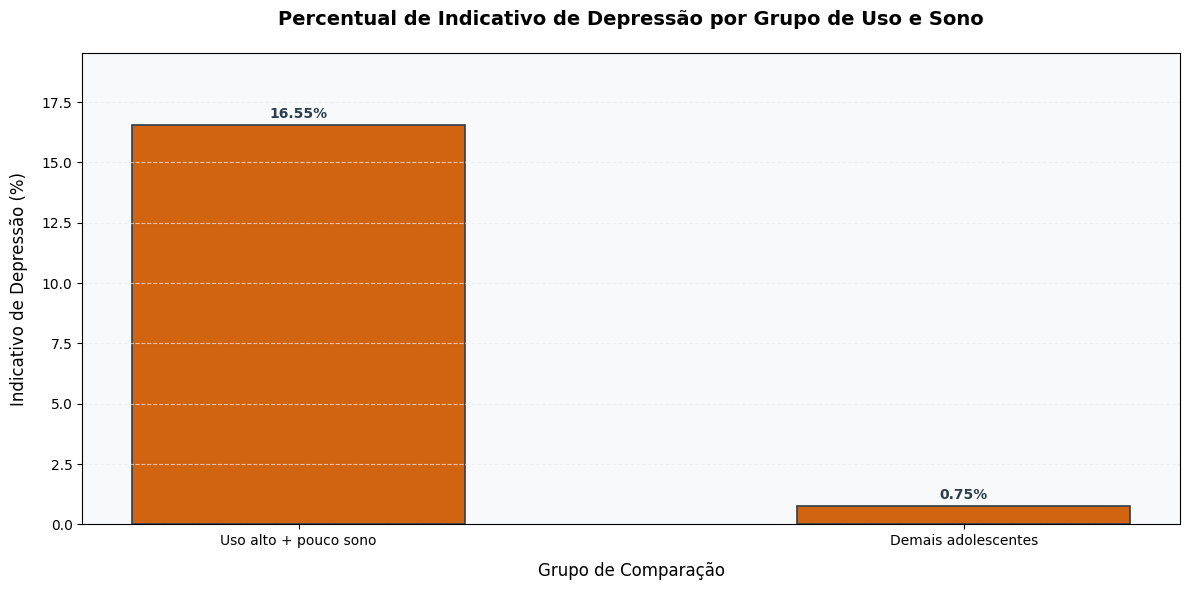

In [2]:
# 1. Criação do grupo de comparação
df['grupo_uso_sono'] = df.apply(
    lambda linha: 'Uso alto + pouco sono'
    if (linha['daily_social_media_hours'] >= 6) and (linha['sleep_hours'] < 6)
    else 'Demais adolescentes',
    axis=1
)

# 2. Agrupamento dos dados e cálculo do percentual de depressão
dados_agrupados = df.groupby('grupo_uso_sono').agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Ordenação dos grupos para deixar o gráfico mais claro
ordem = ['Uso alto + pouco sono', 'Demais adolescentes']
dados_agrupados['grupo_uso_sono'] = pd.Categorical(
    dados_agrupados['grupo_uso_sono'],
    categories=ordem,
    ordered=True
)
dados_agrupados = dados_agrupados.sort_values('grupo_uso_sono').reset_index(drop=True)

display(dados_agrupados)

# 4. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 5. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['grupo_uso_sono'],
    dados_agrupados['percentual_depressao'],
    color="#d16410",
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.5
)

for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Grupo de Uso e Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Grupo de Comparação', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

plt.ylim(0, max(dados_agrupados['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre a relação entre uso de redes sociais, sono e indicativo de depressão:

* **Maior Percentual no Grupo de Risco:** O grupo formado por adolescentes com **uso alto de redes sociais e pouco sono** apresentou **16.55%** de indicativo de depressão. Esse valor é bem maior do que o observado no grupo dos demais adolescentes.
* **Comparação com os Demais Adolescentes:** Entre os **demais adolescentes**, o percentual de indicativo de depressão foi de apenas **0.75%**. Isso mostra uma diferença bastante clara entre os dois grupos analisados.
* **Quantidade de Registros:** O grupo de uso alto de redes sociais e pouco sono possui **139 registros**, enquanto o grupo dos demais adolescentes possui **1061 registros**. Essa diferença de tamanho entre os grupos deve ser considerada na interpretação, mas o contraste percentual continua sendo relevante.
* **Diferença Percentual:** A diferença entre os grupos foi de aproximadamente **15.79 pontos percentuais**. Isso indica que, nesta base, a combinação entre muitas horas em redes sociais e poucas horas de sono está associada a uma maior presença de indicativo de depressão.
* **Validação:** A hipótese foi **confirmada na amostra analisada**. Os adolescentes que combinam uso alto de redes sociais e pouco sono apresentaram um percentual maior de indicativo de depressão. Porém, como esta é uma análise exploratória, não podemos afirmar que o uso de redes sociais e o pouco sono causam depressão. O correto é dizer que, nesta base, esses fatores aparecem associados a uma maior presença do indicador analisado.
